In [1]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [2]:
# LOAD THE DATASET
df = pd.read_csv('matches.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1095, 20)

First 5 rows:


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
# EXPLORE THE DATA
print("Column names:")
print(df.columns.tolist())

print("\nMissing values in each column:")
print(df.isnull().sum())


Column names:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Missing values in each column:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [4]:
# CLEAN THE DATA
df = df.dropna(subset=['winner'])

print(f"Total matches after cleaning: {df.shape[0]}")


Total matches after cleaning: 1090


In [5]:
# ANALYSIS 1: WHICH TEAM WINS THE MOST?
wins = df['winner'].value_counts()

print("Top 10 teams by wins:")
print(wins.head(10))


Top 10 teams by wins:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


C:\Users\aryan\AppData\Local\Temp\ipykernel_29304\1807270067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wins.values[:10], y=wins.index[:10], palette='Blues_r')


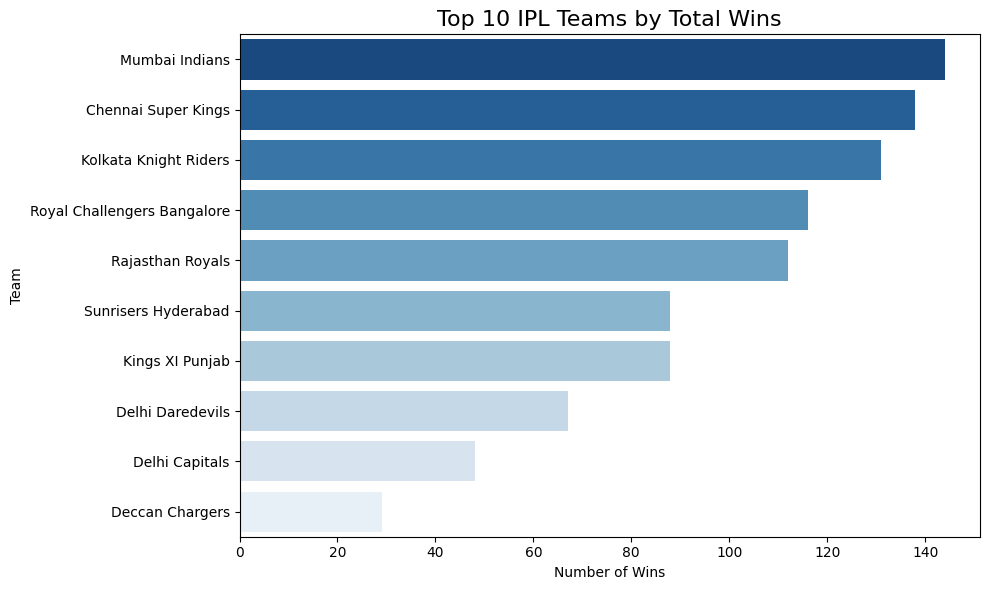

Chart saved


In [6]:
# CHART 1: BAR CHART OF TOP 10 TEAMS
plt.figure(figsize=(10,6))
sns.barplot(x=wins.values[:10], y=wins.index[:10], palette='Blues_r')

plt.title('Top 10 IPL Teams by Total Wins', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('top_teams.png')
plt.show()

print("Chart saved")

In [7]:
# ANALYSIS 2: DOES WINNING TOSS HELP WIN THE MATCH?
df['toss_match_win'] = df['toss_winner'] == df['winner']
toss_win_pct = df['toss_match_win'].mean() * 100

print(f"Winning toss leads to winning match: {toss_win_pct:.1f}% of the time")


Winning toss leads to winning match: 50.8% of the time


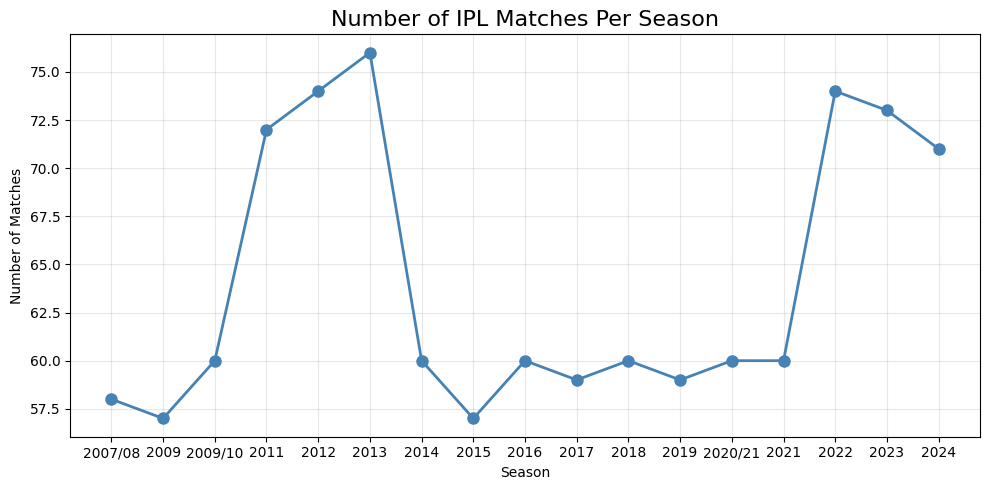

In [8]:
# ANALYSIS 3: MATCHES PER SEASON
matches_per_season = df.groupby('season').size()

plt.figure(figsize=(10, 5))
plt.plot(matches_per_season.index, matches_per_season.values, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Number of IPL Matches Per Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('matches_per_season.png')
plt.show()

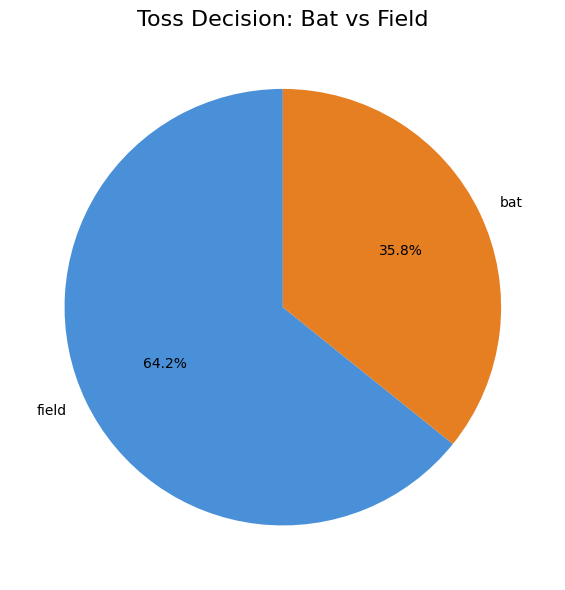

In [9]:
# ANALYSIS 4: TOSS DECISION (BAT vs FIELD)
toss_decision = df['toss_decision'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(toss_decision,
        labels=toss_decision.index,
        autopct='%1.1f%%',
        colors=['#4A90D9', '#E67E22'],
        startangle=90)

plt.title('Toss Decision: Bat vs Field', fontsize=16)
plt.tight_layout()
plt.savefig('toss_decision.png')
plt.show()

C:\Users\aryan\AppData\Local\Temp\ipykernel_29304\2466843274.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette='Greens_r')


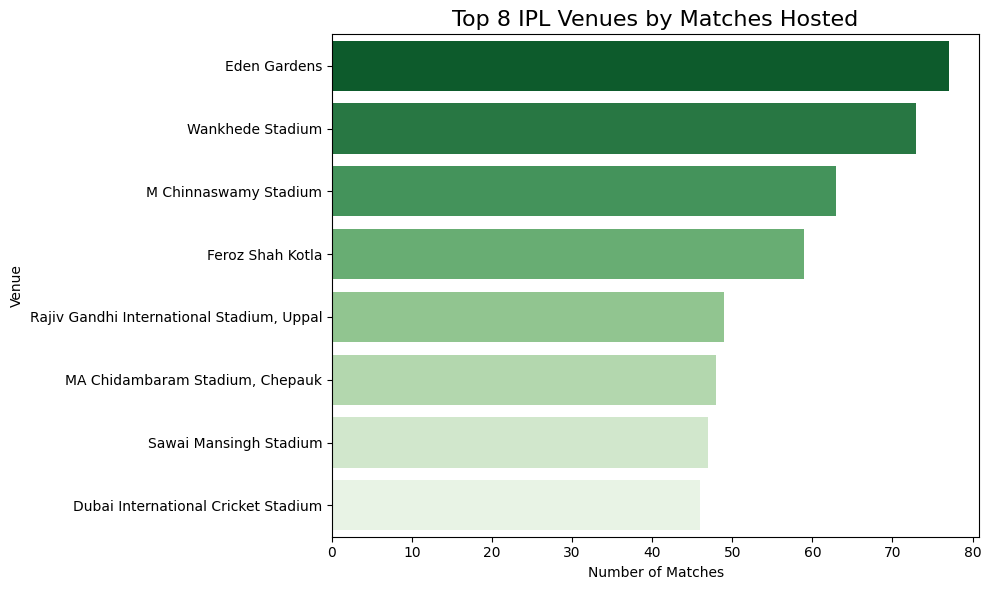

In [10]:
# ANALYSIS 5: TOP VENUES
top_venues = df['venue'].value_counts().head(8)

plt.figure(figsize=(10,6))
sns.barplot(x=top_venues.values, y=top_venues.index, palette='Greens_r')

plt.title('Top 8 IPL Venues by Matches Hosted', fontsize=16)
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.savefig('top_venues.png')
plt.show()

In [11]:
# SUMMARY OF FINDINGS
print("=" * 45)
print("        IPL DATA ANALYSIS — KEY FINDINGS")
print("=" * 45)

print(f"\n✅ Total matches analyzed: {df.shape[0]}")
print(f"\n🏆 Most successful team: {wins.index[0]} ({wins.values[0]} wins)")
print(f"\n🎲 Toss advantage: {toss_win_pct:.1f}% win rate after toss win")
print(f"\n📅 Seasons covered: {df['season'].min()} to {df['season'].max()}")
print(f"\n🏟️  Most used venue: {df['venue'].value_counts().index[0]}")
print(f"\n📊 Charts saved: top_teams.png, matches_per_season.png,")
print(f"   toss_decision.png, top_venues.png")

        IPL DATA ANALYSIS — KEY FINDINGS

✅ Total matches analyzed: 1090

🏆 Most successful team: Mumbai Indians (144 wins)

🎲 Toss advantage: 50.8% win rate after toss win

📅 Seasons covered: 2007/08 to 2024

🏟️  Most used venue: Eden Gardens

📊 Charts saved: top_teams.png, matches_per_season.png,
   toss_decision.png, top_venues.png
